# Blood cells classifiction

### Libraries and Explanation

#### 1. TensorFlow (`tensorflow`)
- A popular deep learning framework for building and training machine learning models.
- Provides high-level APIs for creating neural networks and handling large-scale data.
- **Installation**:  
  ```bash
  pip install tensorflow
  ```

#### 2. Keras (`tensorflow.keras`)
- A high-level API integrated into TensorFlow for building neural networks.
- Simplifies the process of defining, training, and evaluating deep learning models.

#### 3. ImageDataGenerator (`tensorflow.keras.preprocessing.image`)
- Used to generate batches of image data with real-time data augmentation.
- Useful for expanding datasets by applying transformations like rotations, flips, and rescaling.

#### 4. PIL (Python Imaging Library)
- A library for image processing tasks such as opening, manipulating, and saving images.
- Available as `Pillow` (modern fork of PIL).
- **Installation**:  
  ```bash
  pip install pillow
  ```

#### 5. NumPy (`numpy`)
- A fundamental library for numerical computations in Python.
- Provides support for arrays, matrices, and a collection of mathematical functions.
- **Installation**:  
  ```bash
  pip install numpy
  ```

#### 6. Matplotlib (`matplotlib`)
- A library for creating static, animated, and interactive visualizations.
- Used for plotting data, visualizing training metrics, or displaying images.
- **Installation**:  
  ```bash
  pip install matplotlib
  ```

#### 7. OS (`os`)
- A Python standard library for interacting with the operating system.
- Used to navigate file directories and handle file paths.
- No installation needed; it's included with Python.
-
#### 8. Seaborn (`seaborn`)
- A Python library built on top of `matplotlib` for creating informative and attractive statistical graphics.
- Provides high-level functions for creating complex visualizations like heatmaps, bar plots, and violin plots with minimal code.
- Enhances `matplotlib` plots by providing built-in themes, color palettes, and more.
- To install, use:
  ```bash
  pip install seaborn
  ```
#### 9. Time (`time`)
- A Python standard library for measuring and manipulating time-related tasks.
- Provides tools to work with timestamps, delays, and performance measurements.
- No installation needed; it's included with Python.
---

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import seaborn as sns
import time
import pickle
import random
import shutil

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp -r /content/drive/MyDrive/data_cells /content/

## Dataset load
- **`ImageDataGenerator`**: Preprocesses image data by normalizing pixel values (`rescale=1./255`).
- **`flow_from_directory`**: Loads images from directories, resizes them to `(256, 256)`, and processes them in batches of 32.
- **`class_mode='categorical'`**: Encodes labels as one-hot vectors for multi-class classification.
- **Use**: Prepares training and testing datasets for a deep learning model.

In [ ]:
data_dir = '/content/data_cells'
output_dir = '/content/data_split'
SEED = 42

train_ratio = 0.7
val_ratio = 0.1
test_ratio = 0.2

random.seed(SEED)

for split in ['train', 'val', 'test']:
    split_path = os.path.join(output_dir, split)
    if not os.path.exists(split_path):
        os.makedirs(split_path)

categories = os.listdir(data_dir)
for cat in categories:
    cat_path = os.path.join(data_dir, cat)
    if not os.path.isdir(cat_path):
        continue

    images = os.listdir(cat_path)
    random.shuffle(images)

    n_total = len(images)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)
    n_test = n_total - n_train - n_val

    split_dict = {
        'train': images[:n_train],
        'val': images[n_train:n_train+n_val],
        'test': images[n_train+n_val:]
    }

    for split, split_images in split_dict.items():
        split_cat_path = os.path.join(output_dir, split, cat)
        os.makedirs(split_cat_path, exist_ok=True)
        for img in split_images:
            src = os.path.join(cat_path, img)
            dst = os.path.join(split_cat_path, img)
            shutil.copyfile(src, dst)

In [ ]:
real_size = (360,363)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    os.path.join(output_dir, 'train'),
    target_size=real_size,
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

validation_generator = val_test_datagen.flow_from_directory(
    os.path.join(output_dir, 'val'),
    target_size=real_size,
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(output_dir, 'test'),
    target_size=real_size,
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.


## Dataset preview
The code displays images from the `train_generator` and `test_generator` along with their predicted labels.

- It shows a single image from each generator with its one-hot encoded label and the predicted class name.
- For the test generator, it displays a grid of 25 images, labeling each image with its true one-hot encoded label and predicted class based on the maximum value in the labels array.

In [ ]:
images, labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())
label_text = class_names[np.argmax(labels[10])]
plt.imshow(images[10])
plt.title(f'{labels[10]} or {label_text}')
plt.show()

IndexError: index 10 is out of bounds for axis 0 with size 0

In [ ]:
images, labels = next(test_generator)
class_names = list(test_generator.class_indices.keys())
label_text = class_names[np.argmax(labels[10])]
plt.imshow(images[10])
plt.title(f'{labels[10]} or {label_text}')
plt.show()

In [ ]:
import random
import matplotlib.pyplot as plt

images, labels = next(train_generator)

n_display = 25
plt.figure(figsize=(18, 18), facecolor='white')  # white background for the figure
plt.rcParams['axes.facecolor'] = 'white'          # white background for axes

indices = random.sample(range(len(images)), min(n_display, len(images)))

for i, idx in enumerate(indices):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images[idx])
    if len(labels.shape) > 1 and labels.shape[1] > 1:
        plt.xlabel(f'{labels[idx]} or\n{class_names[np.argmax(labels[idx])]}')
    else:
        plt.xlabel(f'{labels[idx]} or\n{class_names[labels[idx]]}')

plt.subplots_adjust(wspace=1, hspace=1)
plt.show()


1. Input Layer:
   - Input(shape=(256, 256, 3)): The model accepts RGB images of size 256x256 pixels with 3 channels.

2. Convolutional Blocks:
   - Block 1:
     - Conv2D(32, (3,3), activation='relu'): Applies 32 filters of size 3x3 with ReLU activation.
     - BatchNormalization(): Normalizes outputs to stabilize and accelerate training.
     - MaxPooling2D(2,2): Downsamples feature maps by taking the maximum from each 2x2 window.
   - Block 2:
     - Conv2D(64, (3,3), activation='relu'): 64 filters of size 3x3.
     - BatchNormalization()
     - MaxPooling2D(2,2)
   - Block 3:
     - Conv2D(128, (3,3), activation='relu'): 128 filters of size 3x3.
     - BatchNormalization()
     - MaxPooling2D(2,2)
   - Block 4:
     - Conv2D(128, (3,3), activation='relu'): Another set of 128 filters.
     - BatchNormalization()
     - MaxPooling2D(2,2)

3. Flattening Layer:
   - Flatten(): Converts the final feature maps into a 1D vector.

4. Fully Connected Layers:
   - Dense(512, activation='relu'): A dense layer with 512 neurons and ReLU activation.
   - BatchNormalization(): Normalizes the output to reduce internal covariate shift.
   - Dropout(0.5): Drops 50% of neurons to reduce overfitting.

5. Output Layer:
   - Dense(train_generator.num_classes, activation='softmax'): Output layer with softmax activation to predict class probabilities. The number of output neurons equals the number of target classes.

This model extracts hierarchical spatial features using stacked convolutional layers and then classifies the extracted patterns using dense layers. Batch normalization ensures stability, and dropout helps generalize better by reducing overfitting.

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation = 'relu', input_shape = (360,363,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation = 'softmax')
])

### Compile

The `model.compile()` function configures the model for training. Here's a breakdown of each parameter:

1. **optimizer**:
   - `'adam'`: The Adam optimizer is used here. It combines the benefits of both the SGD (Stochastic Gradient Descent) and RMSProp optimizers, and it adapts the learning rate during training. It's popular for its efficiency and ease of use.

2. **loss**:
   - `'categorical_crossentropy'`: This is the loss function used for multi-class classification problems. It measures the difference between the true labels and the predicted probabilities. The formula for categorical crossentropy is:

   $$ L = - \sum_{i=1}^{C} y_i \log(p_i) $$

   Where:
   - $L$ is the loss.
   - $C$ is the number of classes.
   - $y_i$ is the true probability distribution (usually 0 or 1).
   - $p_i$ is the predicted probability for each class.

   The lower the value of this loss function, the better the model's predictions match the actual labels.


3. **metrics**:
   - `['accuracy']`: This specifies the metric to evaluate the model's performance during training and testing. Here, 'accuracy' will track the proportion of correctly predicted labels.


In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = [
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')
    ]
)

### Fitting

The `fit()` function is used to train the model. Here's a breakdown of the parameters used in the code:

- `train_generator`: This is the data generator for training. It yields batches of images and labels from the training dataset.
  
- `steps_per_epoch`: This specifies how many batches to process before declaring one epoch finished. It is set to the number of samples in the training dataset (`train_generator.samples`), so the model will go through all the training samples once per epoch.

- `epochs`: The number of times the entire dataset will be passed through the model during training. In this case, it is set to 10 epochs.

- `validation_data`: This is the data generator for validation. It yields batches of images and labels from the validation (or test) dataset.

- `validation_steps`: Similar to `steps_per_epoch`, this specifies how many batches to process for validation before moving to the next epoch. It is set to the number of samples in the test dataset (`test_generator.samples`), so the model will validate using all the test samples once per epoch.

The `fit()` function trains the model on the provided data, adjusting the weights to minimize the loss function and improve the model's performance.

In [ ]:
start_time = time.time()

history = model.fit(
    train_generator,
    steps_per_epoch = train_generator.samples  // train_generator.batch_size,
    epochs = 10,
    validation_data = validation_generator,
    validation_steps = validation_generator.samples // validation_generator.batch_size
)

end_time = time.time()
elapsed_time = end_time - start_time
elapsed_hours = elapsed_time / 3600
print(f"Time taken to train the model: {elapsed_hours:.2f} hours")

In [ ]:
#model = load_model(os.path.join(data_dir,'models/blood_cells_model.h5'))
#from google.colab import files
#model.save('/content/blood_cells_model.h5')
#files.download('/content/blood_cells_model.h5')

### Evaluation

The `evaluate()` function is used to assess the model's performance on the dataset. Here's a breakdown of the code:

- `train_generator`: This is the data generator for the training dataset. The model will evaluate its performance on the training data by calculating the loss and accuracy.

- `test_generator`: This is the data generator for the test dataset. The model will evaluate its performance on the test data by calculating the loss and accuracy.

The `evaluate()` function returns two values:
1. `train_loss` and `test_loss`: These represent the loss of the model on the respective datasets (training and testing).
2. `train_accuracy` and `test_accuracy`: These represent the accuracy of the model on the respective datasets.

- The `print()` statements display the accuracy of the model on both the training and test datasets, formatted to two decimal places.

This function is useful to check how well the model is performing after training and provides insights into whether it is overfitting or underperforming.

In [ ]:
train_loss, train_accuracy, train_top3 = model.evaluate(train_generator)
print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Train Top-3 Accuracy: {train_top3:.2f}")

test_loss, test_accuracy, test_top3 = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Top-3 Accuracy: {test_top3:.2f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for i in range(len(test_generator)):
    images, labels = test_generator[i]
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_labels = [k for k, v in sorted(test_generator.class_indices.items(), key=lambda item: item[1])]
cm = confusion_matrix(y_true, y_pred)

plt.style.use('default')
plt.figure(figsize=(12, 10), facecolor='white')

cmap = sns.color_palette("Blues", as_cmap=True)

ax = sns.heatmap(
    cm, annot=True, fmt='d', cmap=cmap, xticklabels=class_labels, yticklabels=class_labels, cbar=True,
    linewidths=0.8, linecolor='#CCCCCC', square=True,
    annot_kws={"size": 12}  # slightly smaller annotation text
)

# adjust annotation colors
for text in ax.texts:
    if text.get_text() == '0':
        text.set_color('#AAAAAA')
        text.set_weight('normal')
    else:
        text.set_color('#0D1B2A')
        text.set_weight('bold')

# axis labels and title
ax.set_xlabel('Predicted', fontsize=16, color='black')
ax.set_ylabel('True', fontsize=16, color='black')
ax.set_title('Confusion Matrix', fontsize=20, color='black')

# make tick labels smaller
plt.xticks(rotation=45, fontsize=10, color='black')
plt.yticks(fontsize=10, color='black')

plt.tight_layout()
plt.show()

### Save

The `model.save()` function is used to save the trained model to a file so that it can be loaded and used later without needing to retrain.

- `'models/vegetables.h5'`: This is the file path where the model will be saved. The model is saved with the `.h5` extension, which is a standard format for storing Keras models (HDF5 format).

By saving the model:
- You can persist the model's architecture, weights, and optimizer state.
- It allows for easy reloading and inference without retraining, which is particularly useful for deploying the model to production.

Once saved, you can load the model with `keras.models.load_model('path_to_model')` and use it to make predictions.

In [ ]:
model.save('models/blood_cells.h5')
#model.save('models/military_vehicle_classifier_10_classes_MODEL.keras')

### Testing with user input

- The image at `image_path` is loaded, resized to 256x256, and normalized (divided by 255).
- The pre-trained model is loaded from `'models/vegetables.h5'`.
- The image is passed through the model to make a prediction.
- The predicted class index is extracted, and the corresponding class label is printed.
- The image is displayed after reversing the normalization for visualization.
- The probability distribution is shown.

In [ ]:
def load_and_preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.resize((360, 363))
    img = np.array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img

Softmax is used in multi-class classification to convert raw output scores (logits) into probabilities, which sum up to 1. The probability of each class is determined by the formula:
$$ P(y_i) = \frac{e^{z_i}}{\sum_{j=1}^{N} e^{z_j}} $$
Where:
- $P(y_i)$ is the probability of class $i$,
- $z_i$ is the raw score (logit) for class $i$,
- $N$ is the total number of classes.

The Softmax function helps the model choose the class with the highest probability.

## Credit
Data taken from https://www.kaggle.com/datasets/unclesamulus/blood-cells-image-dataset

# CLUSTERING!

In [ ]:
data_dir = '/content/data_cells'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
generator = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

Found 17092 images belonging to 8 classes.


In [ ]:
IMG_SIZE = (224, 224)

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

generator = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

Found 17092 images belonging to 8 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(weights='imagenet', include_top=False)

x = base_model.output
x = GlobalAveragePooling2D()(x)  # ↓ різко зменшує розмір
model = Model(inputs=base_model.input, outputs=x)

/tmp/ipykernel_4149/757218351.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
features = model.predict(generator, verbose=1)

535/535 ━━━━━━━━━━━━━━━━━━━━ 78s 113ms/step


In [ ]:
features.shape  # (~N, 1280)

(17092, 1280)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
features_pca = pca.fit_transform(features)

In [ ]:
import umap

umap_emb = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
).fit_transform(features_pca)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(features_pca)

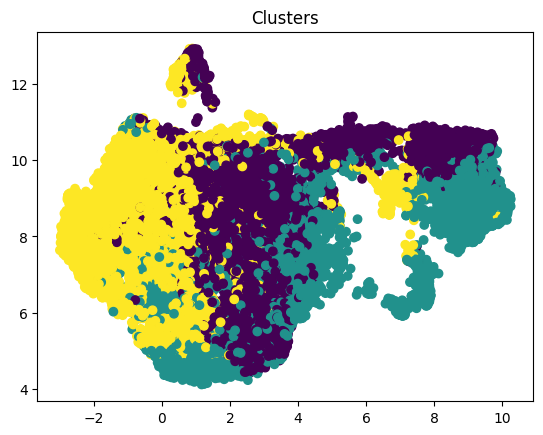

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(umap_emb[:,0], umap_emb[:,1], c=labels)
plt.title("Clusters")
plt.show()